In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [2]:
# Load data
n_proc_array = np.load("n_proc_array.npy")
speedup = np.load("speedup.npy")
time_for_proccesses = np.load("time_for_proccesses.npy")

Estimated parallel fraction according to Amdahl's law:  [0.91277727]


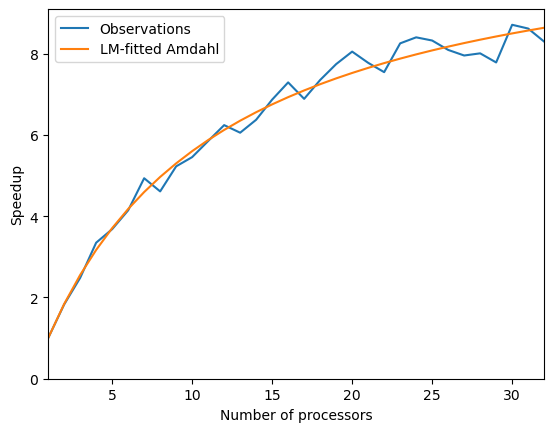

In [3]:
# Fit and plot speed up

n_proc = n_proc_array.flatten()
speedup_observation = speedup.flatten()
T1 = time_for_proccesses[0]

def fun_f(F, n_proc, speedup_observation):
    p = n_proc
    return speedup_observation - T1 / ((1-F)*T1 + F/p *T1)

F0 = np.array([0.9])

# Solve using trust-region-reflective algorithm
from scipy.optimize import least_squares

plt.figure()
plt.plot(n_proc, speedup_observation, label='Observations')

# Solve using levenberg-marquardt algorithm
res = least_squares(fun_f, F0, args=(n_proc, speedup_observation), method='lm', ftol=1e-10, xtol=1e-10)
Fopt = res.x
print("Estimated parallel fraction according to Amdahl's law: ", Fopt)
plt.plot(n_proc, T1 / ((1-Fopt)*T1 + Fopt/n_proc *T1), label='LM-fitted Amdahl')

plt.legend()
plt.xlabel("Number of processors")
plt.ylabel("Speedup")
plt.xlim(np.min(n_proc),np.max(n_proc))
plt.ylim(0)
plt.show()


In [4]:
# Theoretical max speedup
S_max = 1/(1-Fopt)
our_S_max = np.max(speedup_observation)
our_S_max_index = np.argmax(speedup_observation)
our_S_max_cores = n_proc_array[our_S_max_index]

# Time to compute for all buildings
n_buildings = 4571
n_observations = 100
observations_per_chunk = n_observations/our_S_max_cores
all_buildings_per_chunk = n_buildings/our_S_max_cores
times_longer_for_all = all_buildings_per_chunk/observations_per_chunk

# Print results for project handin
print(f"Theoretical max speedup: {S_max}.")
print(f"Acheived of theoretical max speedup: {our_S_max/S_max} using {our_S_max_cores} cores.")
print(f"Theoretically, it would take {times_longer_for_all} times longer computing all buildings.")
print(f"With {n_observations} buildings it took {time_for_proccesses[our_S_max_index]} seconds, meaning {time_for_proccesses[our_S_max_index]/60/60} hours.")
print(f"With {n_buildings} buildings it will estimatetly take {time_for_proccesses[our_S_max_index]*times_longer_for_all} seconds, meaning {time_for_proccesses[our_S_max_index]*times_longer_for_all/60/60} hours.")

Theoretical max speedup: [11.46490075].
Acheived of theoretical max speedup: [0.75992815] using 30 cores.
Theoretically, it would take 45.71 times longer computing all buildings.
With 100 buildings it took 137.1890230178833 seconds, meaning 0.038108061949412034 hours.
With 4571 buildings it will estimatetly take 6270.910242147445 seconds, meaning 1.7419195117076238 hours.


In [6]:
n_buildings/n_observations

45.71